<a href="https://colab.research.google.com/github/javisagredo-dev/Evaluacion2_Prog_DS/blob/main/06_An%C3%A1lisis_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis final de resultados

## Importaciones necesarias

In [17]:
import pickle
import pandas as pd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, adjusted_rand_score
from sklearn.metrics import silhouette_score

##Carga y lectura de datos

In [18]:
drive.mount('/content/drive')
ruta_supervisado = '/content/drive/MyDrive/Ciencia de Datos Collab/Programación para la ciencia de datos/Evaluacion_2/Processed/resultados_svm_optimizado.pkl'
ruta_no_supervisado = '/content/drive/MyDrive/Ciencia de Datos Collab/Programación para la ciencia de datos/Evaluacion_2/Processed/resultados_no_supervisado_optimizado.pkl'

with open(ruta_supervisado, 'rb') as f:
    datos_sup = pickle.load(f)

with open(ruta_no_supervisado, 'rb') as f:
    datos_ns = pickle.load(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:

X_train_svm = datos_sup['X_train_svm']
X_test_svm = datos_sup['X_test_svm']
y_train_svm = datos_sup['y_train_svm']
y_test_svm = datos_sup['y_test_svm']
X_train_svm_scaled = datos_sup['X_train_svm_scaled']
X_test_svm_scaled = datos_sup['X_test_svm_scaled']
svm_reduced = datos_sup['svm_reduced']
scaler_svm = datos_sup['scaler_svm']
acc_svm_r = datos_sup['acc_svm_r']
f1_svm_r = datos_sup['f1_svm_r']
y_pred_svm_r = datos_sup['y_pred_svm_r']
variables_reducidas = datos_sup['variables_reducidas']
le = datos_sup['le']


X_scaled = datos_ns['X_scaled']
y_true = datos_ns['y_true']
mejor_modelo_ns = datos_ns['mejor_modelo_ns']
labels_ganador = datos_ns['labels_ganador']
ari_ganador_ns = datos_ns['ari_ganador_ns']
sil_ganador_ns = datos_ns['sil_ganador_ns']
nombre_ganador_ns = datos_ns['nombre_ganador_ns']

print("Supervisado cargado correctamente")
print(f"Accuracy SVM: {acc_svm_r:.4f} | F1: {f1_svm_r:.4f}")
print(f"Variables usadas: {variables_reducidas}")

print("\nNo supervisado cargado correctamente")
print(f"Modelo ganador: {nombre_ganador_ns}")
print(f"ARI: {ari_ganador_ns:.4f} | Silhouette: {sil_ganador_ns:.4f}")

Supervisado cargado correctamente
Accuracy SVM: 0.9269 | F1: 0.9268
Variables usadas: ['Area', 'MajorAxisLength', 'Eccentricity', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor4']

No supervisado cargado correctamente
Modelo ganador: Jerarquico_GridSearch
ARI: 0.7054 | Silhouette: 0.2738


## Tabla comparativa: Supervisado vs No Supervisado

In [20]:
comparativa = pd.DataFrame({
    'Aspecto': [
        'Paradigma',
        'Modelo',
        'Usa etiquetas',
        'Métrica principal',
        'Valor métrica principal',
        'Métrica secundaria',
        'Valor métrica secundaria',
        'Interpretabilidad',
        'Costo computacional'
    ],
    'Supervisado': [
        'Supervisado',
        'SVM (rbf, C=30)',
        'Sí',
        'Accuracy',
        f'{acc_svm_r:.4f}',
        'F1-Score',
        f'{f1_svm_r:.4f}',
        'Media',
        'Bajo'
    ],
    'No Supervisado': [
        'No Supervisado',
        'Jerárquico (GridSearch)',
        'No',
        'ARI',
        f'{ari_ganador_ns:.4f}',
        'Silhouette',
        f'{sil_ganador_ns:.4f}',
        'Alta',
        'Alto'
    ]
})

print(comparativa.to_string(index=False))

                 Aspecto     Supervisado          No Supervisado
               Paradigma     Supervisado          No Supervisado
                  Modelo SVM (rbf, C=30) Jerárquico (GridSearch)
           Usa etiquetas              Sí                      No
       Métrica principal        Accuracy                     ARI
 Valor métrica principal          0.9269                  0.7054
      Métrica secundaria        F1-Score              Silhouette
Valor métrica secundaria          0.9268                  0.2738
       Interpretabilidad           Media                    Alta
     Costo computacional            Bajo                    Alto


## Comparativa: Aprendizaje Supervisado vs No Supervisado

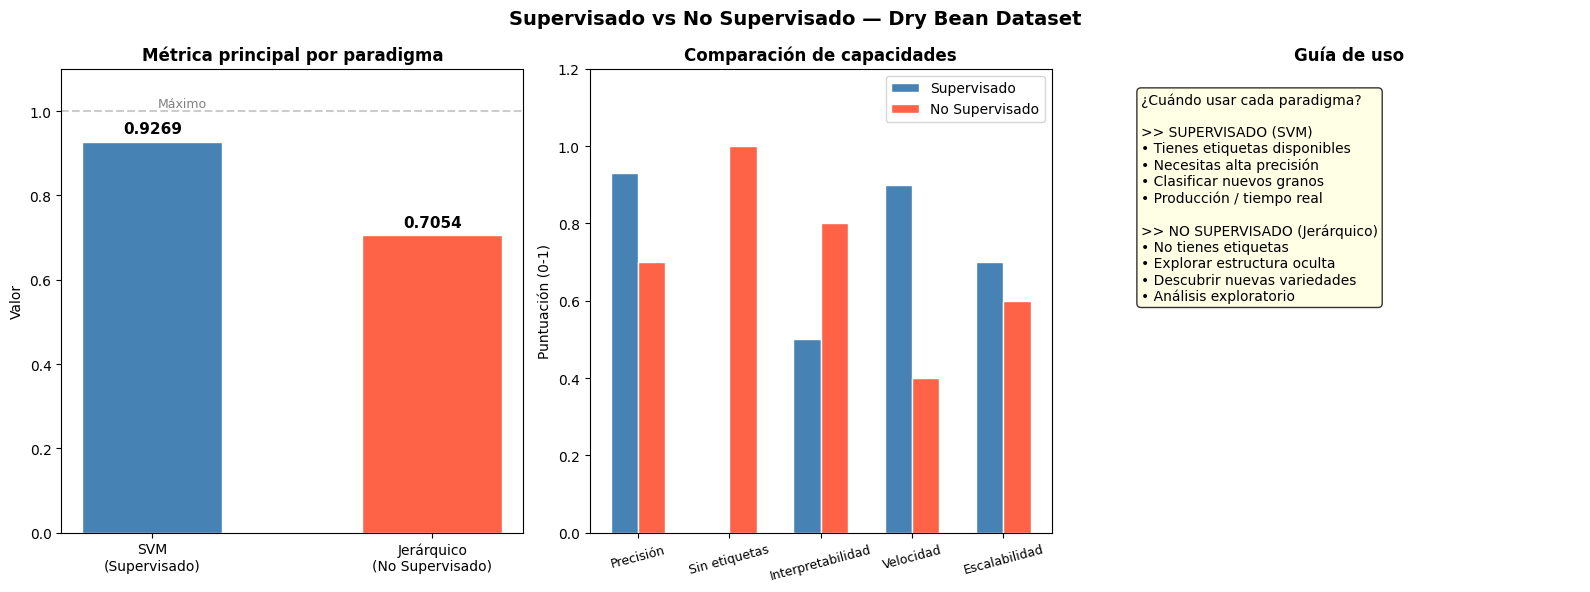

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))


modelos = ['SVM\n(Supervisado)', 'Jerárquico\n(No Supervisado)']
valores = [acc_svm_r, ari_ganador_ns]
colores = ['steelblue', 'tomato']

bars = axes[0].bar(modelos, valores, color=colores, width=0.5, edgecolor='white')
axes[0].set_title('Métrica principal por paradigma', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Valor')
axes[0].set_ylim(0, 1.1)
for bar, val in zip(bars, valores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[0].axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)
axes[0].text(0.02, 1.01, 'Máximo', fontsize=9, color='gray')


categorias = ['Precisión', 'Sin etiquetas', 'Interpretabilidad', 'Velocidad', 'Escalabilidad']
valores_sup = [0.93, 0.0, 0.5, 0.9, 0.7]
valores_ns = [0.70, 1.0, 0.8, 0.4, 0.6]

x = np.arange(len(categorias))
width = 0.3

axes[1].bar(x - width/2, valores_sup, width, label='Supervisado', color='steelblue', edgecolor='white')
axes[1].bar(x + width/2, valores_ns, width, label='No Supervisado', color='tomato', edgecolor='white')
axes[1].set_title('Comparación de capacidades', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categorias, fontsize=9, rotation=15)
axes[1].set_ylim(0, 1.2)
axes[1].legend()
axes[1].set_ylabel('Puntuación (0-1)')


axes[2].axis('off')
texto = (
    "¿Cuándo usar cada paradigma?\n\n"
    ">> SUPERVISADO (SVM)\n"
    "• Tienes etiquetas disponibles\n"
    "• Necesitas alta precisión\n"
    "• Clasificar nuevos granos\n"
    "• Producción / tiempo real\n\n"
    ">> NO SUPERVISADO (Jerárquico)\n"
    "• No tienes etiquetas\n"
    "• Explorar estructura oculta\n"
    "• Descubrir nuevas variedades\n"
    "• Análisis exploratorio"
)
axes[2].text(0.05, 0.95, texto, transform=axes[2].transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[2].set_title('Guía de uso', fontsize=12, fontweight='bold')

plt.suptitle('Supervisado vs No Supervisado — Dry Bean Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusiones

ELECCIÓN DEL MODELO: SUPERVISADO (SVM con kernel rbf)

Para el problema de clasificación de variedades de frijol del
dataset Dry Bean, el modelo supervisado es la elección óptima
cuando se dispone de etiquetas, logrando un accuracy de 92.69%
y F1-Score de 92.68% con solo 10 variables tras eliminar
redundancias.

COMPARACIÓN DE PARADIGMAS:

El aprendizaje supervisado (SVM) superó ampliamente al no
supervisado en términos de precisión (92.69% vs ARI 70.54%).
Esto era esperable: el SVM aprovecha la información de las
etiquetas para construir fronteras de decisión óptimas, mientras
que el clustering jerárquico debe inferir la estructura sin
ninguna guía.

Sin embargo, el clustering jerárquico demostró que el dataset
tiene estructura natural real — un ARI de 0.70 indica que los
grupos encontrados sin etiquetas se alinean significativamente
con las variedades reales. Esto valida que las características
morfológicas del grano son suficientemente discriminativas para
separar las variedades, tanto con como sin supervisión.

CUÁNDO USAR CADA UNO:

El supervisado es ideal en producción: clasificar nuevos granos
automáticamente con alta confianza. El no supervisado es valioso
en exploración: descubrir agrupaciones naturales en lotes sin
etiquetar, o detectar posibles nuevas variedades no catalogadas.

LÍMITE TÉCNICO:

El techo práctico del dataset con algoritmos clásicos está en
~92.7%. Las clases BARBUNYA, CALI y SIRA presentan solapamiento
morfológico que ningún algoritmo clásico puede resolver
completamente sin técnicas más avanzadas.

